## **Business Understanding**
Predict the age of abalone from physical measurements

Source:https://archive.ics.uci.edu/dataset/1/abalone

Loading Library

In [53]:

import pandas as pd #for data manipulation and reading the data frame
from sklearn.linear_model import LinearRegression# we use sklearn as it cmposes many ML algorithms that w can use for our model
from sklearn.model_selection import train_test_split # we split the data into training and testing data
import seaborn as sns #for data visualization
from sklearn.metrics import r2_score #to check the accuracy of our model
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt # aids in visualizatio

Loading data

In [9]:
columns = ["Sex","Length","Diameter","Height","Whole weight","Shucked weight","Viscera weight","Shell weight","Rings"]

In [10]:
df =pd.read_csv("C:\\Users\\USER\\Documents\\ML series\\LinearRegression\\data\\abalone.data",names=columns) #reading the data frame and naming the columns

## **Data Understanding**

In [11]:
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [12]:
rows,colummns =df.shape
output = f"The dataset has {rows} rows and {colummns} columns"
print(output)

The dataset has 4177 rows and 9 columns


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   str    
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 297.9 KB


In [34]:
df.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [15]:
df.describe(include="object") #to check the categorical data

C:\Users\USER\AppData\Local\Temp\ipykernel_140\3743259621.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object") #to check the categorical data


,Sex
count,4177
unique,3
top,M
freq,1528


In [18]:
df['Sex'].unique()

<ArrowStringArray>
['M', 'F', 'I']
Length: 3, dtype: str

In [41]:
df.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [58]:
encoder = OneHotEncoder(handle_unknown='ignore') # instance of the model (transformer based) -
encoder.fit(df[['Sex']]) # fit to get the classes 
encoder.categories_ # lists our categories
encoded_furnishing_status= encoder.transform(df[['Sex']]).toarray()

#  the essence of this DF is basically to represent the valiues in independent features
encoded_df = pd.DataFrame(
    encoded_furnishing_status, 
    columns= encoder.get_feature_names_out(['Sex'])
) 

KeyError: "None of [Index(['Sex'], dtype='str')] are in the [columns]"

In [43]:
df.describe(include="all") #to check the categorical data

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Sex_I,Sex_M
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177,4177
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2835,2649
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684,NaN,NaN
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169,NaN,NaN
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000,NaN,NaN
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000,NaN,NaN
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000,NaN,NaN
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000,NaN,NaN


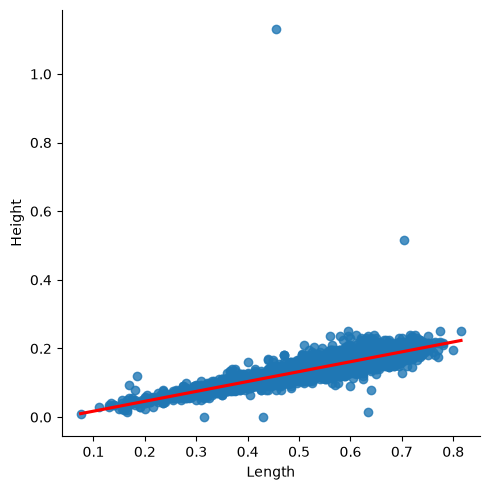

In [51]:
sns.lmplot(data=df, x = 'Length', y = 'Height', line_kws = {"color":"red"})

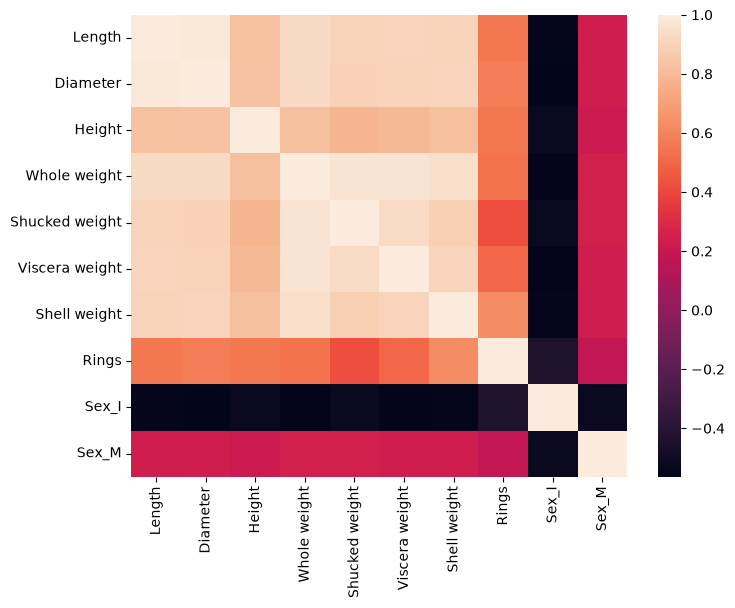

In [57]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df.corr())
plt.show()

## **Data preparation**

## **Modelling**

## **Deployment**